# Multimodal AutoML LOOCV — SC × FC coupling  [지역 · Spearman · PCA 5 · end]

SC(구조 연결, streamline 개수)와 FC(기능 연결)를 **같은 DK 84 ROI**(피질 68 + 피질하 16)로 맞춰 결합한다.
MSN–FC 쪽의 `multimodal_msn_fc68/automl_multimodal_MSN_FC68_coupling_PCA5_spearman.ipynb`와 같은 구성을 SC–FC로 옮긴 것이다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → scale → PCA)도 같다.

## 데이터 (루트와 `sc_dk84/`의 CSV를 `../`로 읽음)

| 파일 | 내용 |
|---|---|
| `sc_dk84/sc_strength_84_end.csv` | SC strength 84개 (streamline 총수). 모델에 넣을 때 log(1 + count) |
| `fc_strength_68_16.csv` | FC strength 84개 |
| `sc_dk84/sc_full_84x84_end.csv`, `fc_full_84x84_edited.csv` | edge 3486개씩 → coupling 계산에만 사용 |

## 표본
SC 45명 ∩ FC 44명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 | nuisance (fold 안 train에서만 fit) |
|---|---|---|
| `Clinical_ONLY` | 없음 | — |
| `SC_PCA5` | SC strength 84 (log) → PCA 5 | age, sex, eTIV |
| `FC84_PCA5` | FC strength 84 → PCA 5 | age, sex, mean_fd |
| `Multimodal` | SC PCA5 + FC84 PCA5 (따로 줄여서 붙임, 10개) | 모달리티별로 따로 |
| `Coupling_S_PCA5` | ROI별 SC–FC coupling(Spearman) (pass 84개 / end는 계산 불가 영역 제외) → PCA 5 | age, sex, eTIV, mean_fd |

**PCA 성분 수만 3 → 5로 바꾼 민감도 분석**이다. 나머지(데이터, coupling 정의, nuisance, 모델, 그리드, LOOCV)는
`..._coupling_PCA3_spearman_end.ipynb`와 같다. 주 분석은 PCA 3이며, 이 노트북은 결론이 성분 수에 따라 달라지는지 확인하는 용도로만 본다.

## coupling 정의 (결과를 보기 전에 정한 규칙)

- 영역 i마다: SC 행렬의 i행(다른 83개 영역과의 streamline 수)과 FC 행렬의 i행의 **Spearman 순위 상관**. 사람당 영역 수만큼 값이 나온다.
- **partner가 3개 미만인 사람이 한 명이라도 있는 영역은 뺀다.** 3은 Spearman이 ±1 이외의 값을 낼 수 있는 최소 개수다.
  없는 값을 채워 넣지 않는다. pass에서는 해당 영역이 없고, end에서는 일부 영역이 빠진다(데이터 준비 셀이 출력한다).
- **SC가 0인 쌍은 뺀다** (Baum 2020, Qian 2026). streamline이 없는 쌍까지 넣으면 "연결이 있나 없나"가 순위를 지배한다.
- SC 값은 변환하지 않는다. Spearman은 순위만 쓰므로 log를 해도 결과가 같다.
- vas를 쓰지 않고 피험자 안에서만 계산하므로 CV 밖에서 미리 계산해도 leakage가 없다.

## 연결 기준: **end** — streamline의 양 끝점이 두 영역 안에 있을 때만 센다 (Chu 2025, Qian 2026 방식). **민감도 분석**

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 같은 사람들로 구한 영역별 coupling의 pass와 end 사이
상관이 0.525였다. 그래서 같은 분석을 두 기준으로 따로 만들었고(`..._pass.ipynb`, `..._end.ipynb`),
**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.

## 읽을 때 주의

- **coupling을 PCA로 줄이는 것은 coupling 문헌에 선례가 없는 우리 설계다.** MSN–FC 쪽과 같은 구성으로 맞추려고 만들었다.
- **이 노트북은 영역별 전부 · 전역 · ROI 결과를 본 뒤에 추가했다.** 미리 정한 분석이 아니므로 탐색적 결과로 읽는다.
- 잔차화 직전에 nuisance를 train 기준으로 표준화한다. 잔차는 수학적으로 같고, eTIV(백만 단위)로 인한 계산 정밀도
  문제를 막는다.
- `SC_PCA3`, `FC84_PCA3`, `Multimodal`(PCA 3)은 이 폴더의 다른 노트북과 같은 방식으로 계산한다 (같은 연결 기준끼리는 같은 값).
  `SC_PCA5`는 `sc_dk84/`의 SC PCA5 strength 노트북과 같은 계산이다.

### 같은 폴더의 변형

| 파일 | 내용 |
|---|---|
| `..._coupling_all_spearman_{pass,end}.ipynb` | 영역별 coupling 전부 (압축 없음) |
| `..._coupling_global_spearman_{pass,end}.ipynb` | 전역 coupling (사람당 1개) |
| `..._coupling_ROI_spearman_{pass,end}.ipynb` | Morph ROI 10개의 coupling |
| `..._coupling_PCA3_spearman_{pass,end}.ipynb` | 영역별 coupling → PCA 3 |
| `..._coupling_PCA5_spearman_{pass,end}.ipynb` | 영역별 coupling → PCA 5, SC·FC도 PCA 5 |
| `..._joint_PCA3_{pass,end}.ipynb` | SC 84 + FC 84를 먼저 붙이고 PCA 3 한 번 |


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC 84 + FC 84, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'            # 데이터 CSV는 TMS 루트와 sc_dk84/ 에 있다
SC_RULE = 'end'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

sc_s = load(f'sc_dk84/sc_strength_84_{SC_RULE}.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s = load('fc_strength_68_16.csv')                    # 앞 7열: ... mean_fd
sc_e = load(f'sc_dk84/sc_full_84x84_{SC_RULE}.csv')
fc_e = load('fc_full_84x84_edited.csv')

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
N_ROI = 84
ROIS = [c[:-len('_sc')] for c in sc_s.columns[7:]]
assert len(ROIS) == N_ROI, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'
sc_edge_cols, fc_edge_cols = list(sc_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_sc')] for c in sc_edge_cols] == fc_edge_cols, 'edge 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = sc_s.merge(fc_s, on='rid', suffixes=('_s', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_s'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 (SC에만 있는 sub-001이 빠진다) ---
df = (sc_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# edge 표도 df와 같은 rid 순서로 맞춘다
E_sc = sc_e.set_index('rid').loc[df['rid'], sc_edge_cols].values.astype(float)   # (44, 3486) streamline 개수
E_fc = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values                 # (44, 3486) Fisher z

IU = np.triu_indices(N_ROI, k=1)

# ---- ROI별 structure–function coupling ----
MIN_PARTNERS = 3          # Spearman이 +1/-1 이외의 값을 낼 수 있는 최소 개수

def to_matrix(edge_row):
    M = np.zeros((N_ROI, N_ROI))
    M[IU] = edge_row
    return M + M.T          # 대각은 0이라 아래에서 자동으로 빠진다

def coupling(sc_edges, fc_edges):
    """ROI i: SC i행과 FC i행의 Spearman rho. SC가 0이 아닌 partner만 쓴다 (Baum 2020, Qian 2026).

    partner가 MIN_PARTNERS 미만이거나 SC 값이 전부 같아 순위를 매길 수 없으면 NaN을 돌려준다.
    """
    S, F = to_matrix(sc_edges), to_matrix(fc_edges)
    out = np.full(N_ROI, np.nan)
    for i in range(N_ROI):
        k = S[i] > 0
        if k.sum() >= MIN_PARTNERS and np.ptp(S[i, k]) > 0:
            out[i] = spearmanr(S[i, k], F[i, k]).statistic
    return out

C_all = np.array([coupling(E_sc[k], E_fc[k]) for k in range(len(df))])            # (44, 84)
n_partner = np.array([(to_matrix(E_sc[k]) > 0).sum(1) for k in range(len(df))])    # (44, 84)

# 한 명이라도 계산할 수 없는 영역은 뺀다. 없는 값을 채워 넣지 않는다.
keep = ~np.isnan(C_all).any(axis=0)
ROIS_CP = [r for r, k in zip(ROIS, keep) if k]
X_coup = C_all[:, keep]
assert np.all(np.isfinite(X_coup))
dropped = [(r, int(np.isnan(C_all[:, j]).sum())) for j, r in enumerate(ROIS) if not keep[j]]

X_sc       = np.log1p(df[[f'{r}_sc' for r in ROIS]].values)   # SC를 피처로 쓸 때는 log(1 + count) (Tong 2026)
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_sc  = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values     # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'연결 기준 {SC_RULE}  |  n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'SC strength {X_sc.shape[1]} | FC strength {X_fc.shape[1]} | coupling {X_coup.shape[1]} (영역별, PCA 5로 줄임)')
print(f'0이 아닌 partner 수: 평균 {n_partner.mean():.1f}, 최소 {n_partner.min()}')
print(f'제외한 영역 {len(dropped)}개 (영역, 계산 불가 인원): {dropped}')
print(f'coupling 전체 평균 {X_coup.mean():+.3f} (SD {X_coup.std():.3f}) | '
      f'피험자별 전뇌 평균 {X_coup.mean(1).min():+.3f} ~ {X_coup.mean(1).max():+.3f}')


연결 기준 end  |  n = 44  |  Active 25 / Sham 19
SC strength 84 | FC strength 84 | coupling 82 (영역별, PCA 5로 줄임)
0이 아닌 partner 수: 평균 34.5, 최소 1
제외한 영역 2개 (영역, 계산 불가 인원): [('rh_transversetemporal', 6), ('rh_Accumbens', 1)]
coupling 전체 평균 +0.199 (SD 0.216) | 피험자별 전뇌 평균 +0.118 ~ +0.276


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 5   # 민감도 분석: PCA 3 노트북에서 이 값만 바꿈

DATA_TYPES = ['Clinical_ONLY', 'SC_PCA5', 'FC84_PCA5', 'Multimodal', 'Coupling_S_PCA5']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → scale → PCA → stack → StandardScaler
#    coupling도 같은 방식으로 PCA(N_PCA)로 줄인다
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_only(X, N, tr, te):
    """nuisance 회귀 잔차. nuisance 표준화와 회귀 모두 train에서만 fit한다.

    nuisance를 먼저 표준화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    피처 수 > 인원일 때 LinearRegression의 계산이 깨져 RMSE가 수십억으로 나온다.
    """
    nz = StandardScaler().fit(N[tr])
    reg = LinearRegression().fit(nz.transform(N[tr]), X[tr])
    return X[tr] - reg.predict(nz.transform(N[tr])), X[te] - reg.predict(nz.transform(N[te]))

def resid_pca(X, N, tr, te):
    """resid_only → 표준화 → PCA(N_PCA). 전부 train에서만 fit."""
    X_tr, X_te = resid_only(X, N, tr, te)
    sc = StandardScaler().fit(X_tr)
    pca = PCA(n_components=N_PCA, random_state=42).fit(sc.transform(X_tr))
    return (pca.transform(sc.transform(X_tr)), pca.transform(sc.transform(X_te)),
            pca.explained_variance_ratio_.sum())

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
evr_log = {'SC': [], 'FC84': [], 'Coupling': []}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_sc)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Xs_tr, Xs_te, ev_s = resid_pca(X_sc, X_nuis_sc, tr, te)
    Xf_tr, Xf_te, ev_f = resid_pca(X_fc, X_nuis_fc, tr, te)
    Xp_tr, Xp_te, ev_p = resid_pca(X_coup, X_nuis_cp, tr, te)
    evr_log['SC'].append(ev_s)
    evr_log['FC84'].append(ev_f)
    evr_log['Coupling'].append(ev_p)

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'SC_PCA5':       (np.hstack([Xs_tr, Xc_tr]),        np.hstack([Xs_te, Xc_te])),
        'FC84_PCA5':     (np.hstack([Xf_tr, Xc_tr]),        np.hstack([Xf_te, Xc_te])),
        'Multimodal':    (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        'Coupling_S_PCA5': (np.hstack([Xp_tr, Xc_tr]),        np.hstack([Xp_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print(f'PCA{N_PCA} 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))


Starting LOOCV: 6 models x 5 datasets x 44 folds ...





LOOCV done.
PCA5 누적 설명분산 평균: SC 33.0%  |  FC84 82.5%  |  Coupling 32.9%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Multi_vs_SC':   ('SC_PCA5',      'Multimodal'),
    'd_Multi_vs_FC84':  ('FC84_PCA5',     'Multimodal'),
    'd_Coup_vs_Clin':   ('Clinical_ONLY', 'Coupling_S_PCA5'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,SC_PCA5,FC84_PCA5,Multimodal,Coupling_S_PCA5,d_Multi_vs_SC,d_Multi_vs_FC84,d_Coup_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,
LinearRegression,1.997,1.971,2.037,1.901,2.040,0.069,0.136,-0.043,0.096
ElasticNet,1.996,2.085,2.134,2.061,2.159,0.024,0.073,-0.163,-0.065
SVR_Linear,2.041,2.116,2.048,1.940,2.195,0.175,0.108,-0.154,0.100
SVR_RBF,2.208,2.188,2.091,1.942,2.179,0.246,0.149,0.029,0.266
RandomForest,2.201,2.184,2.271,2.245,2.255,-0.061,0.025,-0.054,-0.045
XGBoost,2.235,2.221,2.399,2.249,2.323,-0.028,0.149,-0.088,-0.014



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Multi_vs_SC     4/6   (선형·커널 4개 중 4)
  d_Multi_vs_FC84   6/6   (선형·커널 4개 중 4)
  d_Coup_vs_Clin    1/6   (선형·커널 4개 중 1)
  d_Multi_vs_Clin   3/6   (선형·커널 4개 중 3)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,Multimodal,LinearRegression,1.9015,0.2901,0.5614,0.0001
1,Multimodal,SVR_Linear,1.9402,0.2609,0.5255,0.0002
2,Multimodal,SVR_RBF,1.9421,0.2595,0.5171,0.0003
3,SC_PCA5,LinearRegression,1.9706,0.2376,0.5014,0.0005
4,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
5,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010
6,FC84_PCA5,LinearRegression,2.0370,0.1853,0.4697,0.0013
7,Coupling_S_PCA5,LinearRegression,2.0403,0.1827,0.4474,0.0023
8,Clinical_ONLY,SVR_Linear,2.0406,0.1824,0.4494,0.0022
9,FC84_PCA5,SVR_Linear,2.0482,0.1763,0.4554,0.0019


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,SC_PCA5,FC84_PCA5,Multimodal,Coupling_S_PCA5
Model,,,,,
LinearRegression,1.997,1.971,2.037,1.901,2.040
ElasticNet,1.996,2.085,2.134,2.061,2.159
SVR_Linear,2.041,2.116,2.048,1.940,2.195
SVR_RBF,2.208,2.188,2.091,1.942,2.179
RandomForest,2.201,2.184,2.271,2.245,2.255
XGBoost,2.235,2.221,2.399,2.249,2.323



===== Active  RMSE =====


Data Type,Clinical_ONLY,SC_PCA5,FC84_PCA5,Multimodal,Coupling_S_PCA5
Model,,,,,
LinearRegression,2.004,1.927,1.977,1.827,2.059
ElasticNet,2.003,2.133,2.120,2.115,2.209
SVR_Linear,2.055,2.086,2.083,1.905,2.282
SVR_RBF,2.291,2.179,1.904,1.809,2.236
RandomForest,2.261,2.203,2.407,2.269,2.285
XGBoost,2.341,2.092,2.493,2.160,2.226



===== Sham  RMSE =====


Data Type,Clinical_ONLY,SC_PCA5,FC84_PCA5,Multimodal,Coupling_S_PCA5
Model,,,,,
LinearRegression,1.989,2.027,2.113,1.995,2.015
ElasticNet,1.988,2.019,2.153,1.988,2.091
SVR_Linear,2.022,2.154,2.001,1.986,2.074
SVR_RBF,2.095,2.199,2.314,2.105,2.101
RandomForest,2.118,2.160,2.079,2.214,2.214
XGBoost,2.089,2.380,2.269,2.361,2.446


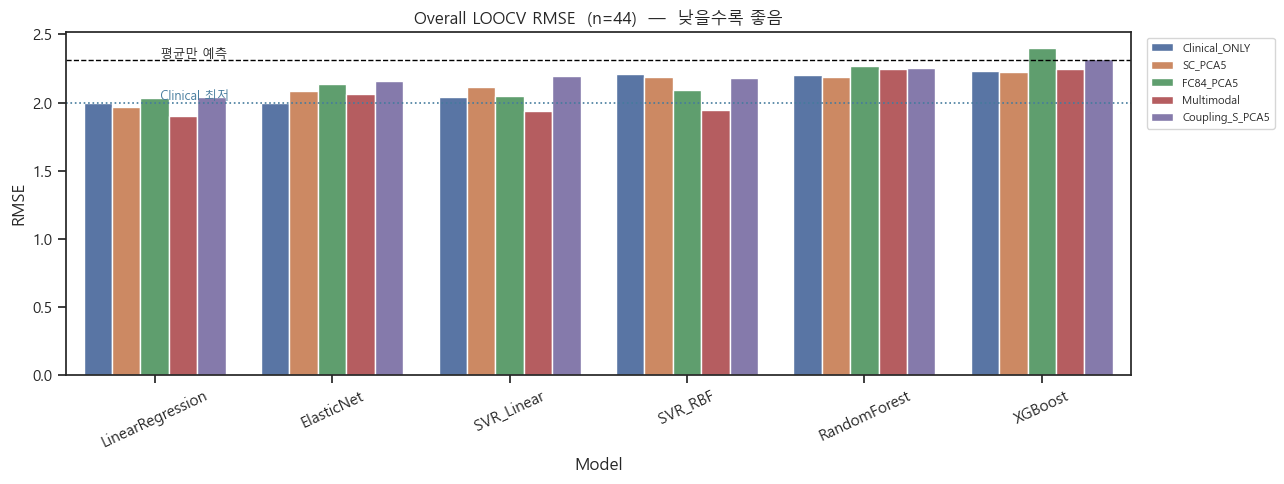

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[SC_PCA5 / LinearRegression] 고유 1개, 최빈 100%
[SC_PCA5 / ElasticNet] 고유 6개, 최빈 77%
[SC_PCA5 / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[SC_PCA5 / SVR_RBF] 고유 11개, 최빈 32%   <-- 불안정
[SC_PCA5 / RandomForest] 고유 10개, 최빈 39%   <-- 불안정
[SC_PCA5 / XGBoost] 고유 9개, 최빈 34%   <-- 불안정
[FC84_PCA5 / LinearRegression] 고유 1개, 최빈 100%
[FC84_PCA5 / ElasticNet] 고유 8개, 최빈 32%   <-- 불안정
[FC84_PCA5 / SVR_Linear] 고유 11개, 최빈 32%   <-- 불안정
[FC84_PCA5 / SVR_RBF] 고유 12개, 최빈 32%   <-- 불안정
[FC84_PCA5 / RandomForest] 고유 8개, 최빈 59%
[FC84_PCA5 / XGBoost] 고유 6개, 최빈 36%   <-- 불안정
[Multimodal / LinearRegression] 고유 1개, 최빈 100%
[Multimodal / ElasticNet] 고유 8개, 최빈 23%   <-- 불안정
[Multimodal / SVR_Linear] 고유 6개, 최빈 59%
[Multimodal / SVR_RBF] 고유 7개, 최빈 50%
[Multi

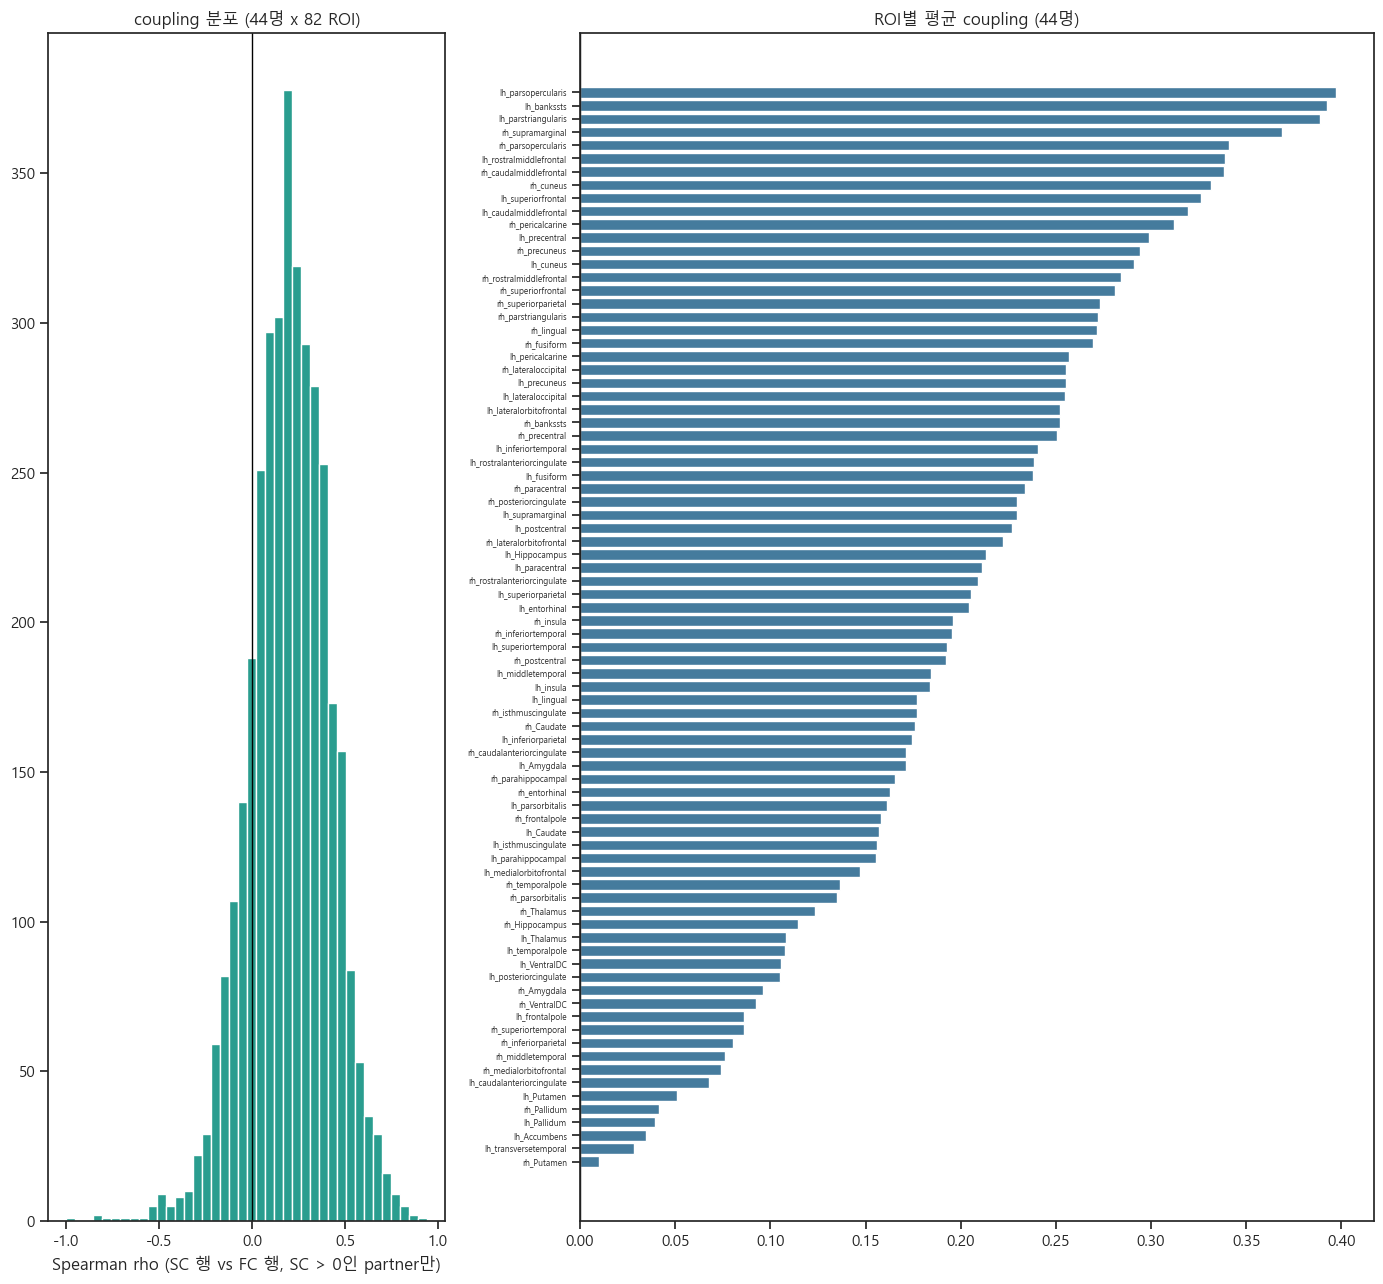

상위 5:
lh_parsopercularis     0.397
lh_bankssts            0.393
lh_parstriangularis    0.389
rh_supramarginal       0.369
rh_parsopercularis     0.341

하위 5:
rh_Putamen               0.010
lh_transversetemporal    0.028
lh_Accumbens             0.035
lh_Pallidum              0.039
rh_Pallidum              0.041

0이 아닌 partner 수가 가장 적은 영역 (사람들 중 최소값):
rh_transversetemporal    1
rh_Accumbens             2
rh_frontalpole           3
lh_frontalpole           3
lh_pericalcarine         4
lh_paracentral           5
lh_Accumbens             5
rh_pericalcarine         5


In [9]:
# ==========================================================
# 8. Coupling 기술통계 (sanity check — 예측과 무관, vas를 쓰지 않음)
#    선행연구: 감각·시각 피질은 coupling이 높고 연합 피질(DMN 등)은 낮다.
# ==========================================================
cp = pd.DataFrame(X_coup, columns=ROIS_CP)
roi_mean = cp.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 13), gridspec_kw={'width_ratios': [1, 2]})
axes[0].hist(X_coup.ravel(), bins=40, color='#2A9D8F', edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title(f'coupling 분포 ({X_coup.shape[0]}명 x {X_coup.shape[1]} ROI)')
axes[0].set_xlabel('Spearman rho (SC 행 vs FC 행, SC > 0인 partner만)')

colors = ['#E63946' if v < 0 else '#457B9D' for v in roi_mean.values]
axes[1].barh(roi_mean.index, roi_mean.values, color=colors)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title(f'ROI별 평균 coupling ({X_coup.shape[0]}명)')
axes[1].tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

print('상위 5:'); print(roi_mean.tail(5)[::-1].round(3).to_string())
print('\n하위 5:'); print(roi_mean.head(5).round(3).to_string())

# partner가 적은 영역은 coupling이 불안정하다. 빼지는 않고 어디인지 적어 둔다.
few = pd.Series(n_partner.min(0), index=ROIS).sort_values().head(8)
print('\n0이 아닌 partner 수가 가장 적은 영역 (사람들 중 최소값):'); print(few.to_string())


## 결과 읽는 법

1. **따로 줄여서 붙이면 이득인가**: `Multimodal`이 `SC_PCA5`와 `FC84_PCA5` **둘 다**보다 낮아야 한다
   (`d_Multi_vs_SC`, `d_Multi_vs_FC84` 둘 다 +). 한쪽만 이기면 그 모달리티 하나가 끌고 간 것이다.
2. **coupling이 정보를 더하는가**: `d_Coup_vs_Clin`이 +.
3. **Active와 Sham**: 5번 셀과 10번 셀에서 군별 RMSE, r, R2를 나란히 본다. 모델은 44명 전체로 학습한 것이다.
4. **기준선**: `Clinical_ONLY`, 평균 예측 RMSE와 비교한다. 같은 44명이라 FC 단독·SC 단독(44명) 노트북과 기준선이 같다.
5. **연결 기준**: pass가 주 분석이다. end에서 방향이 다르면 결론이 연결 기준에 달려 있다는 뜻이고, 그렇게 적는다.
6. **하지 말 것**: coupling이 튀는 영역을 골라 피처로 쓰는 것. 같은 44명으로 고르면 leakage다.
   all / global / ROI / PCA 3 / PCA 5 중 잘 나온 것만 골라 보고하는 것도 같은 문제다. 전부 보고한다.


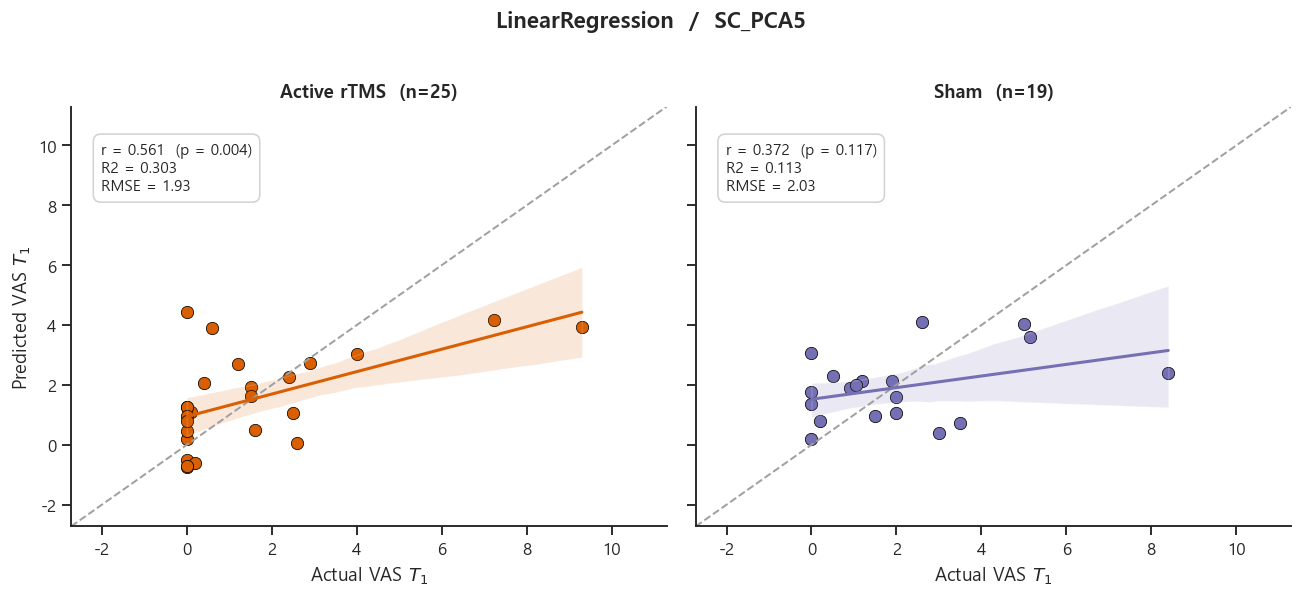

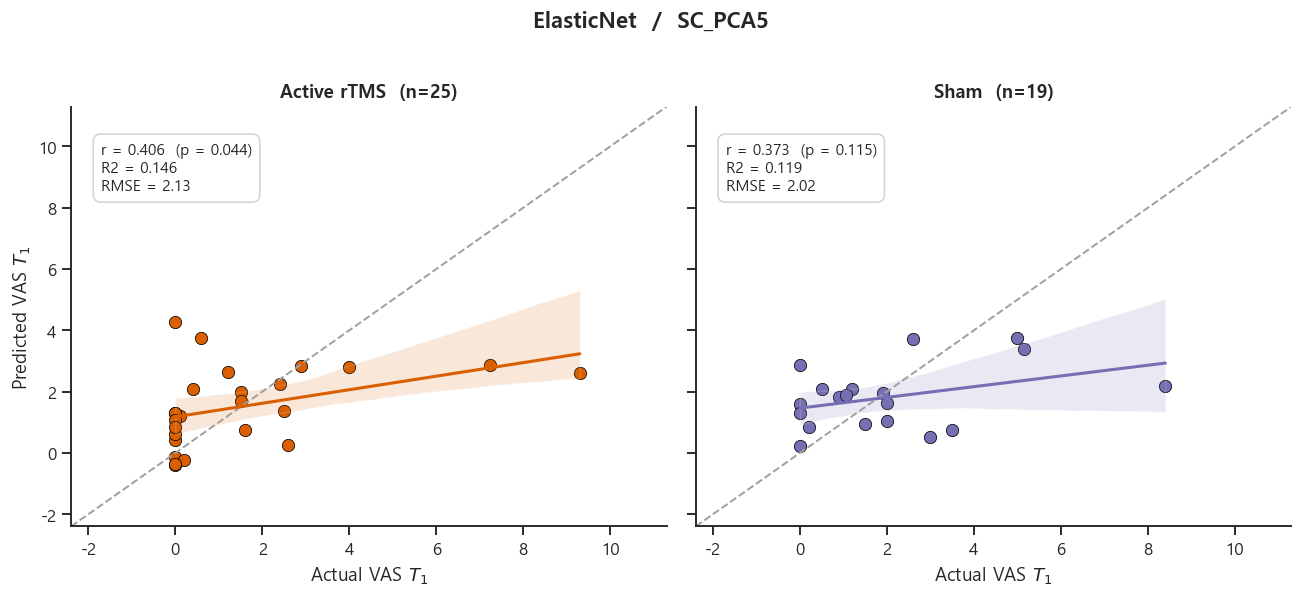

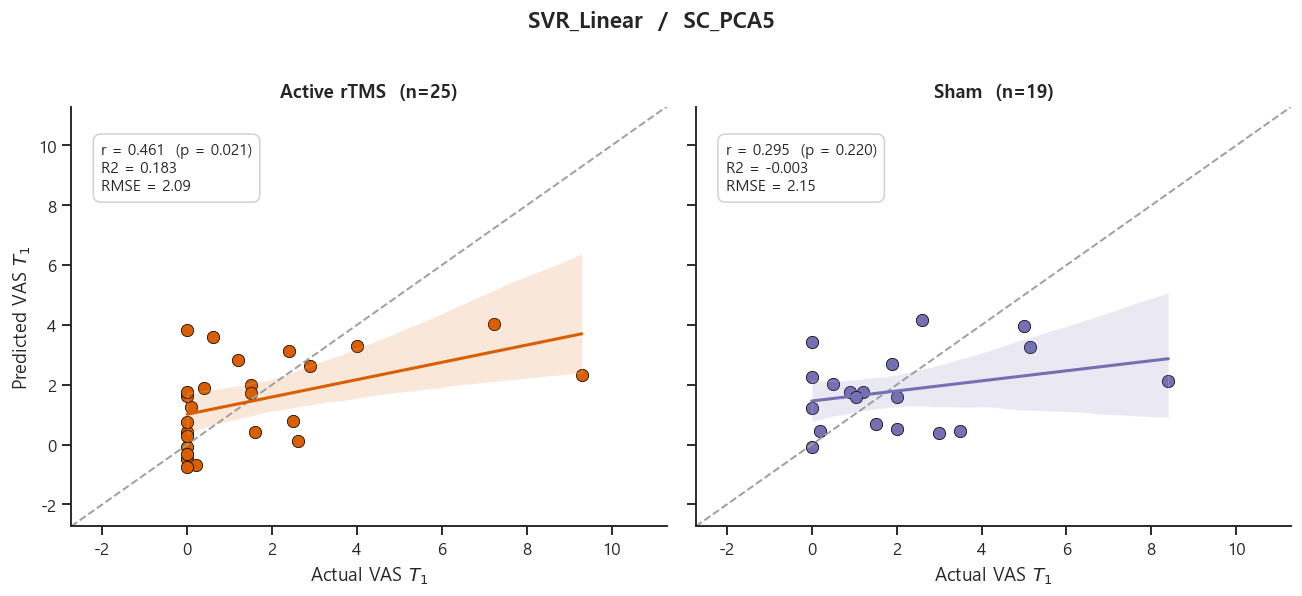

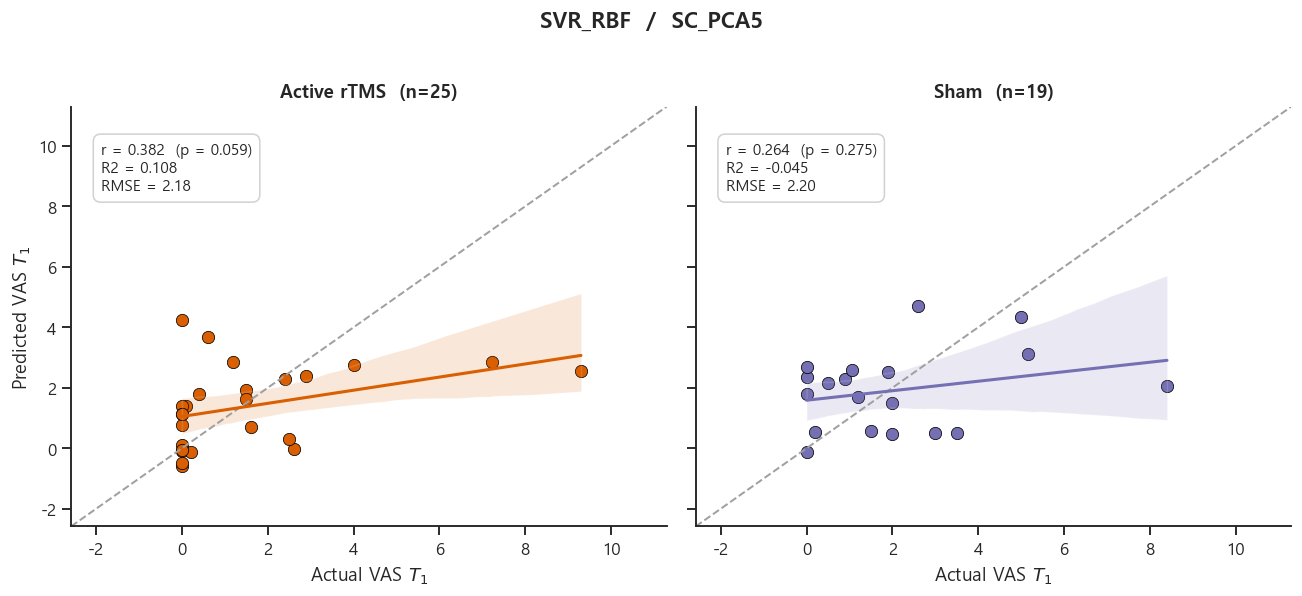

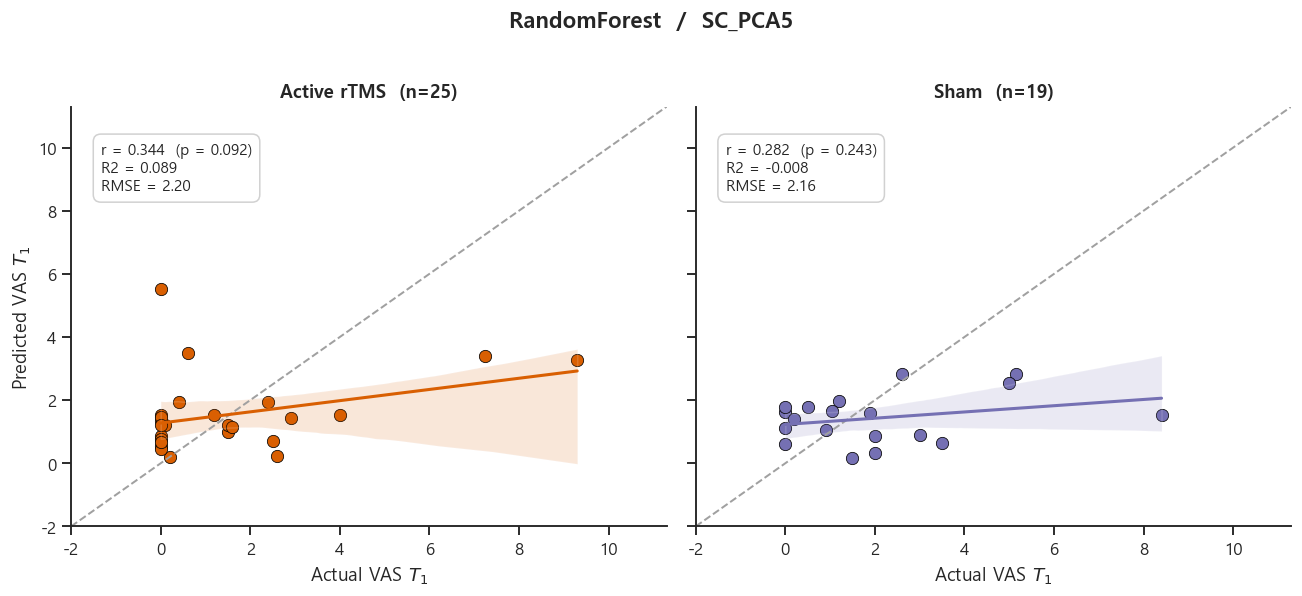

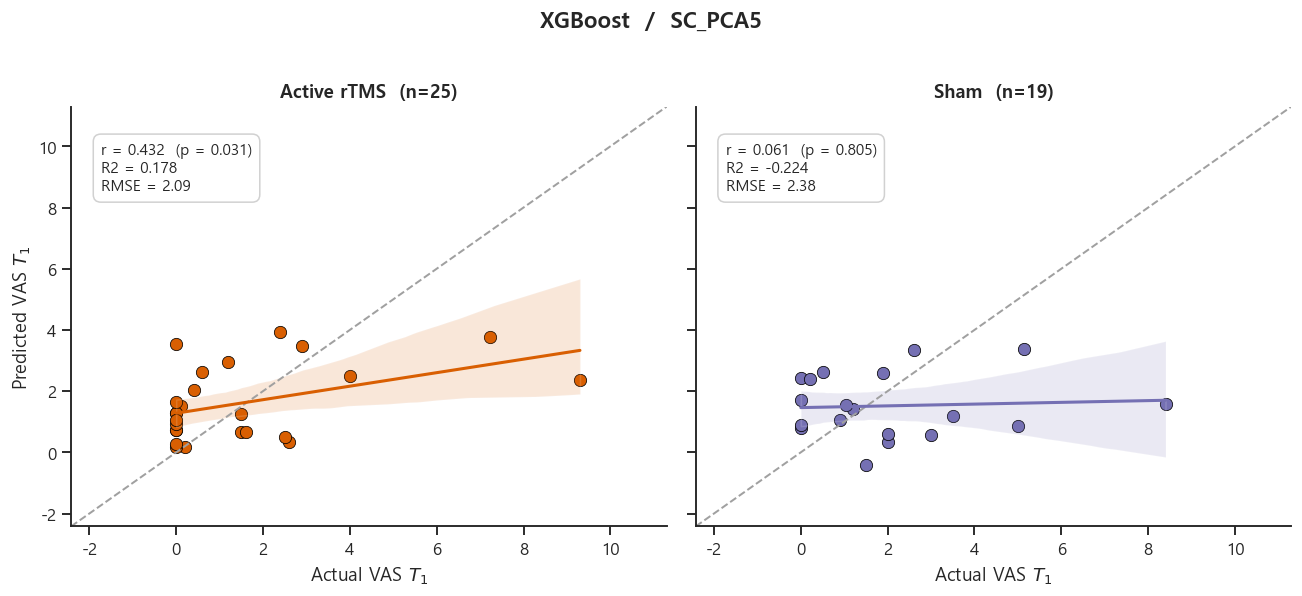

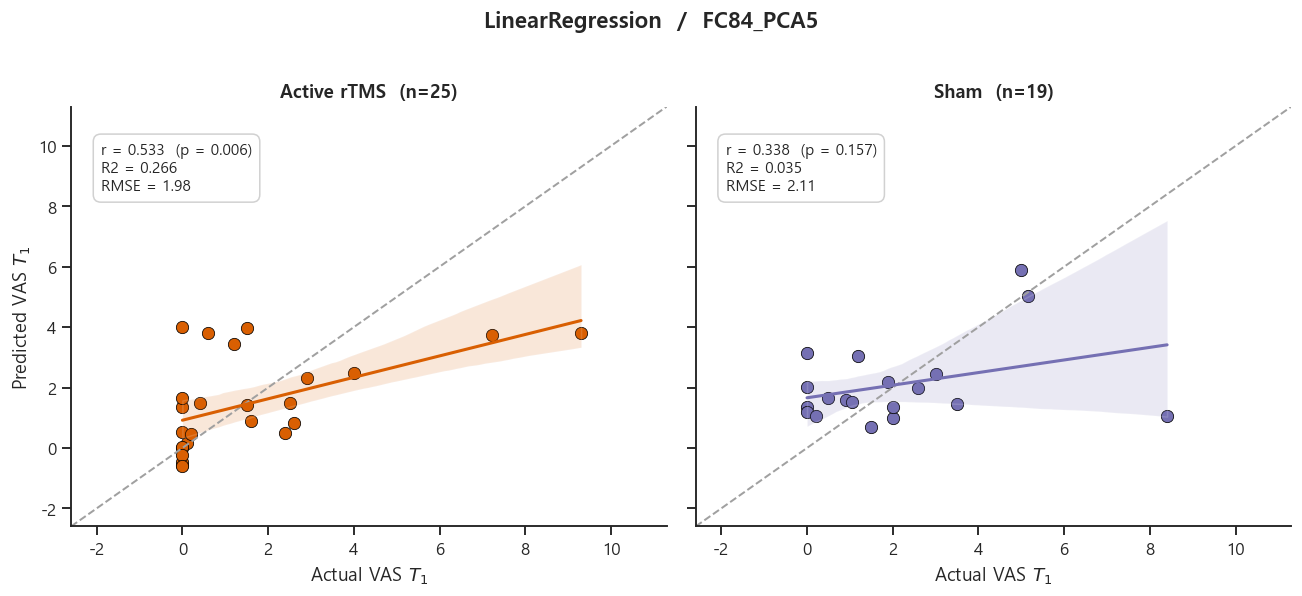

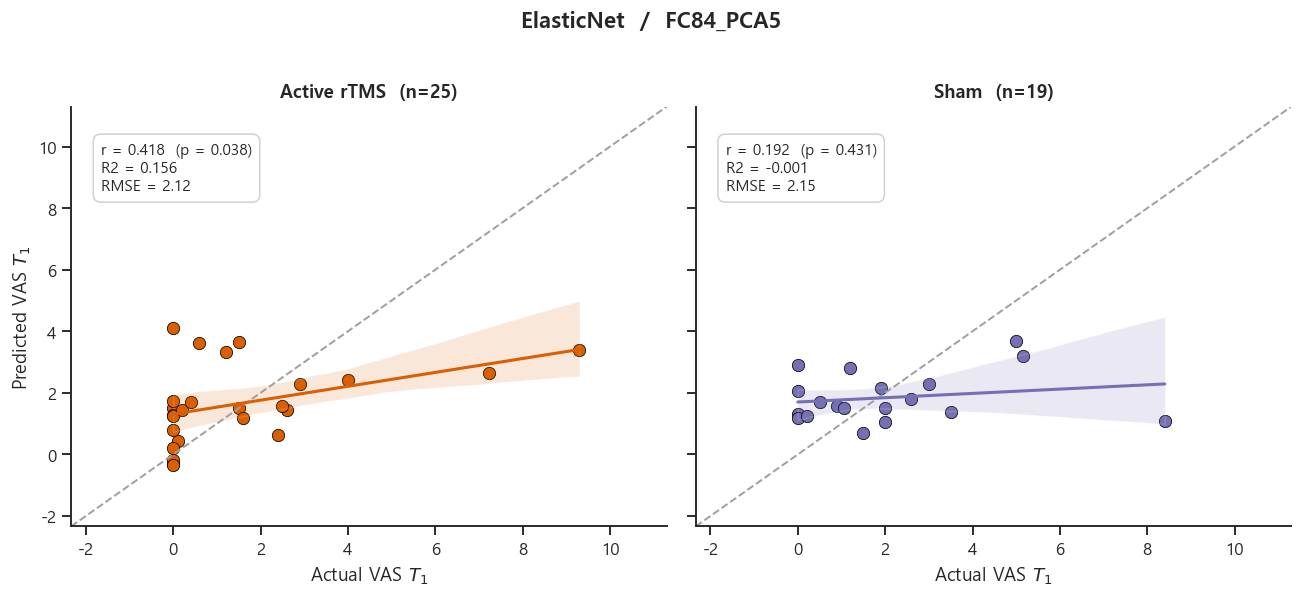

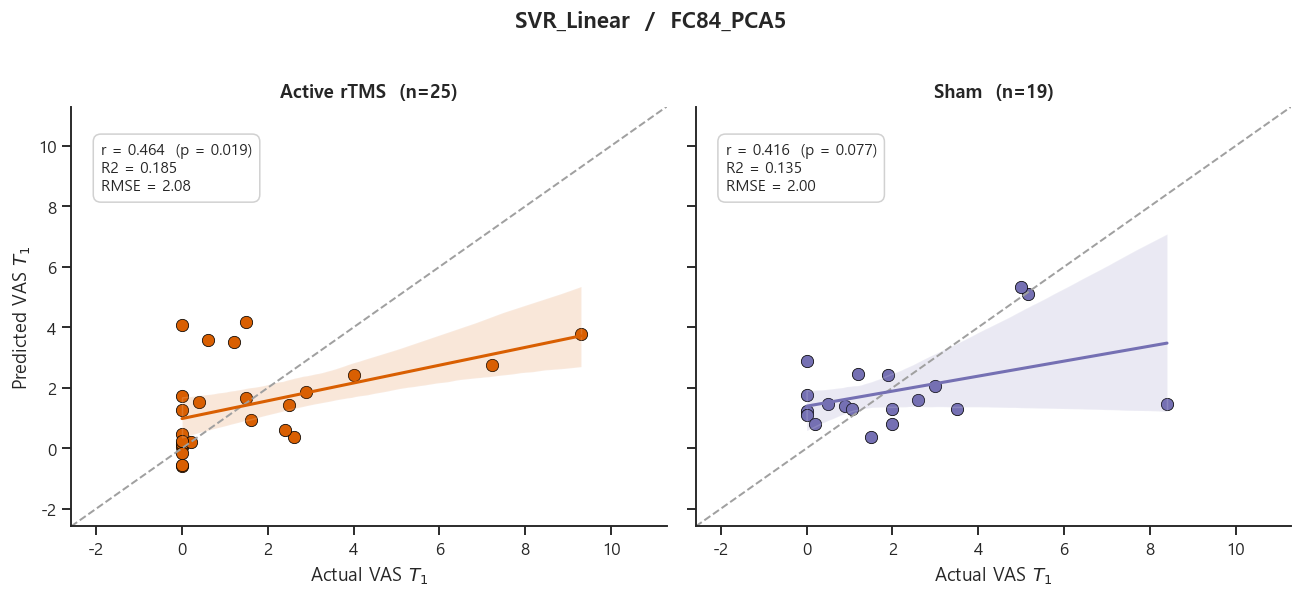

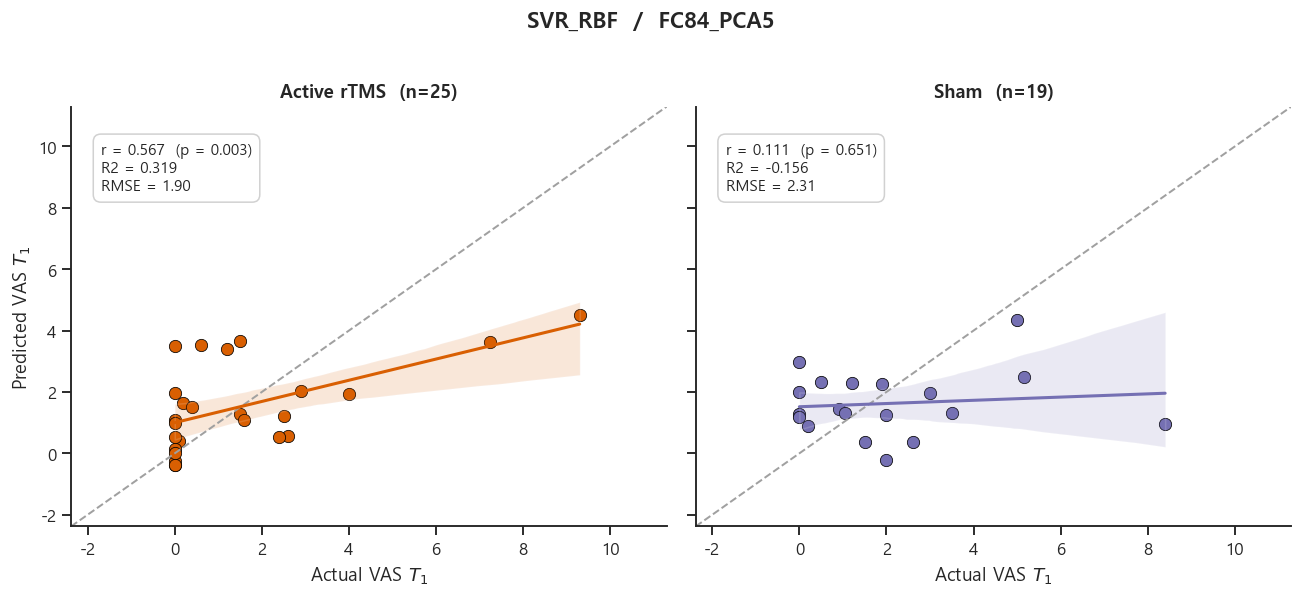

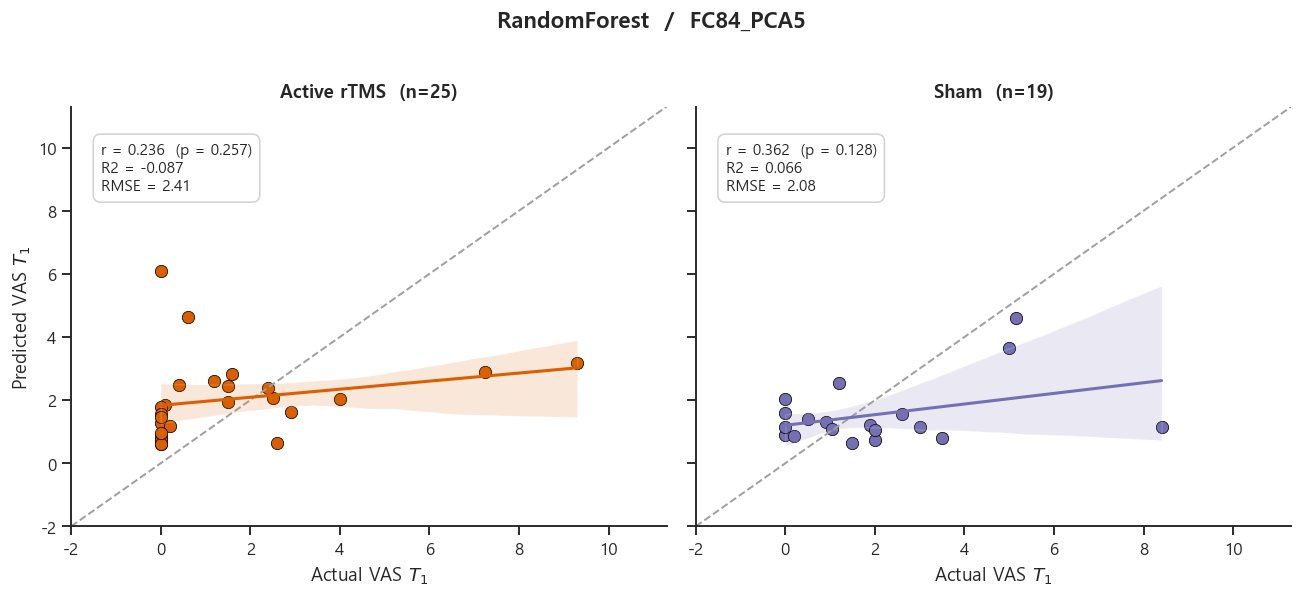

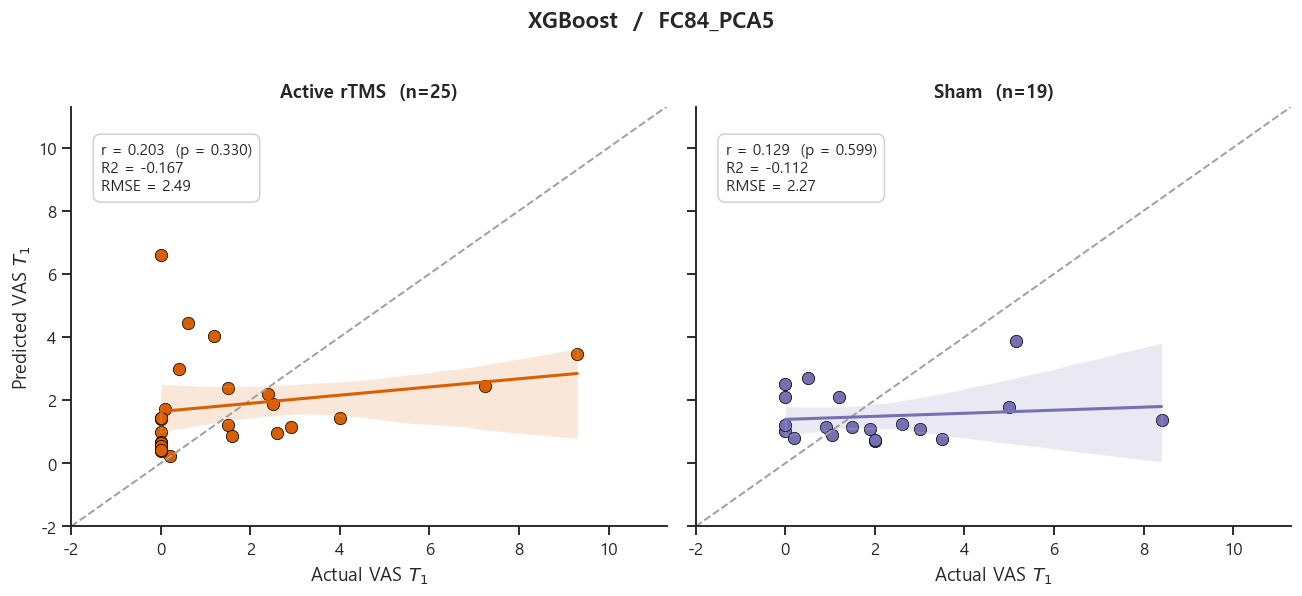

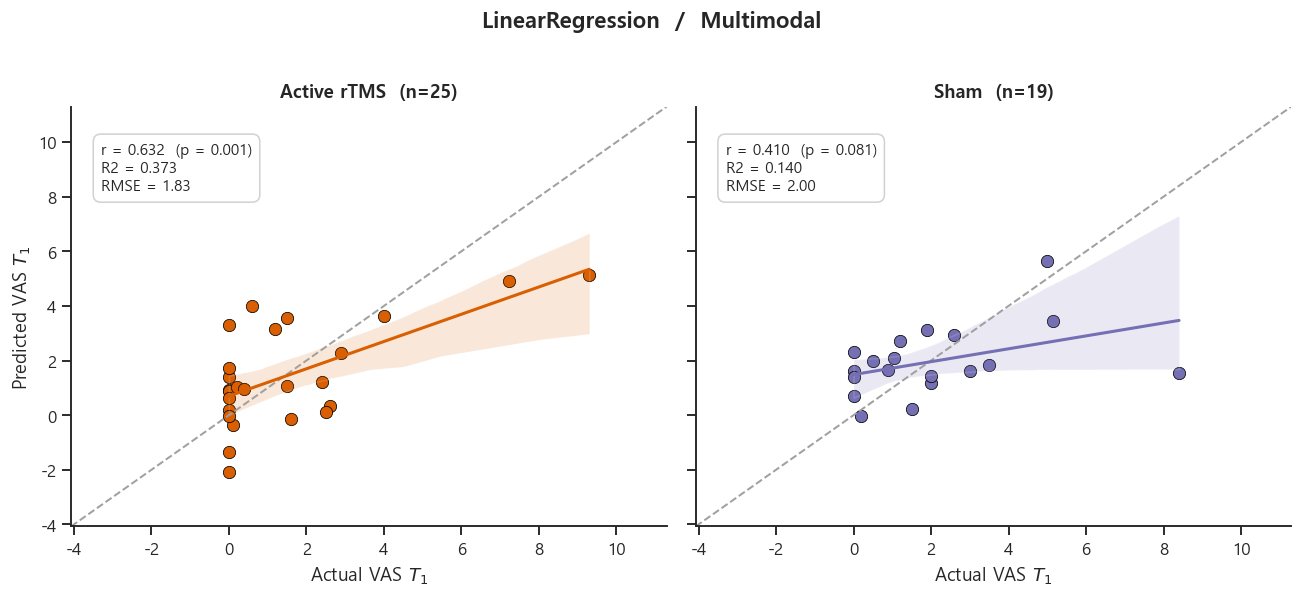

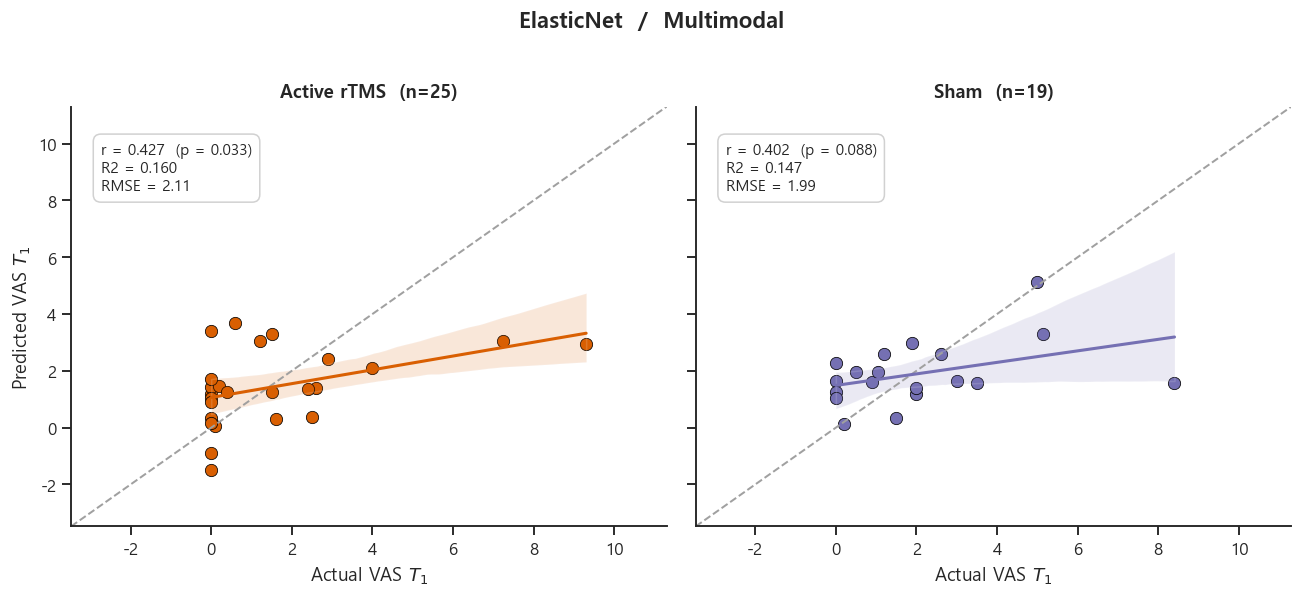

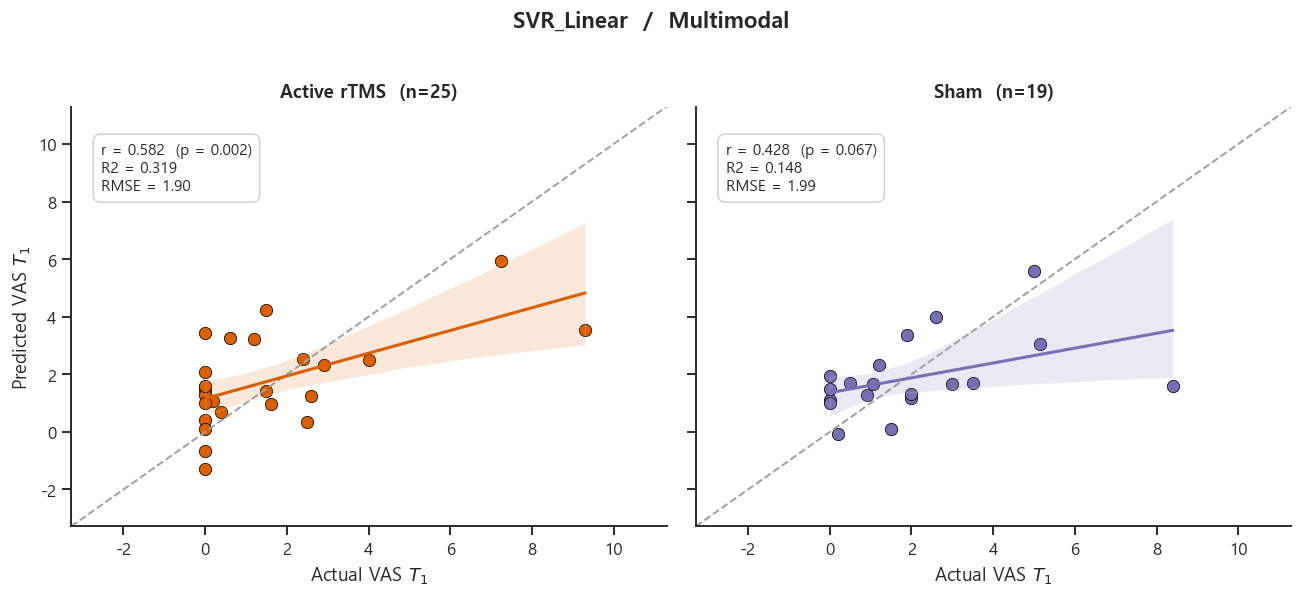

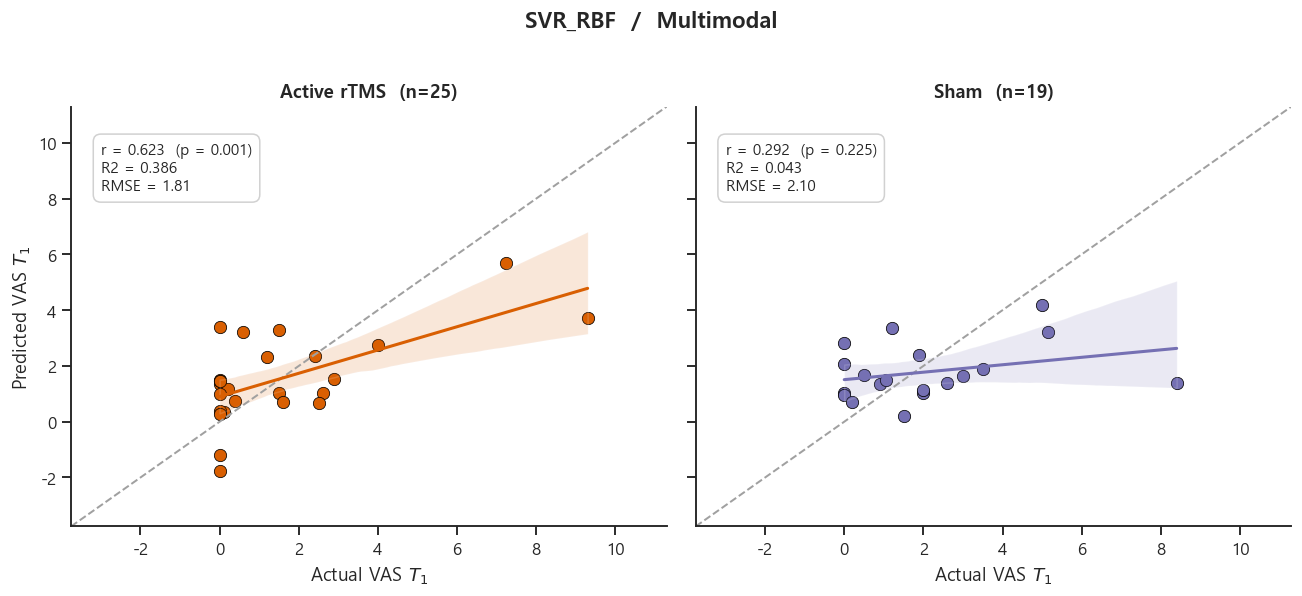

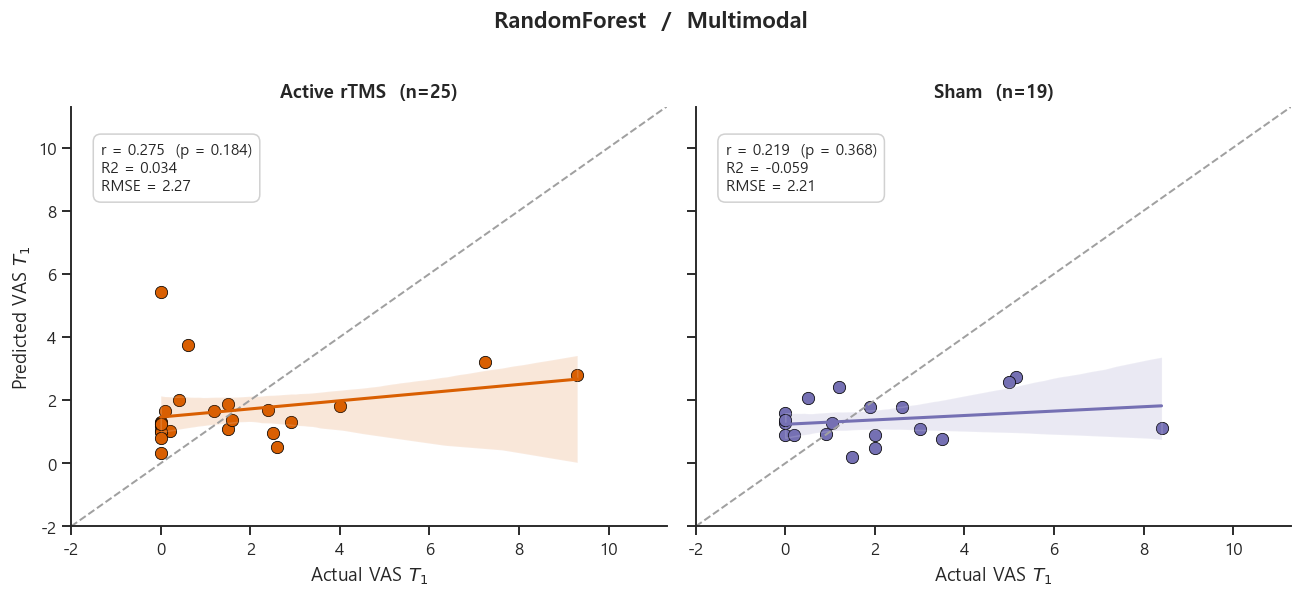

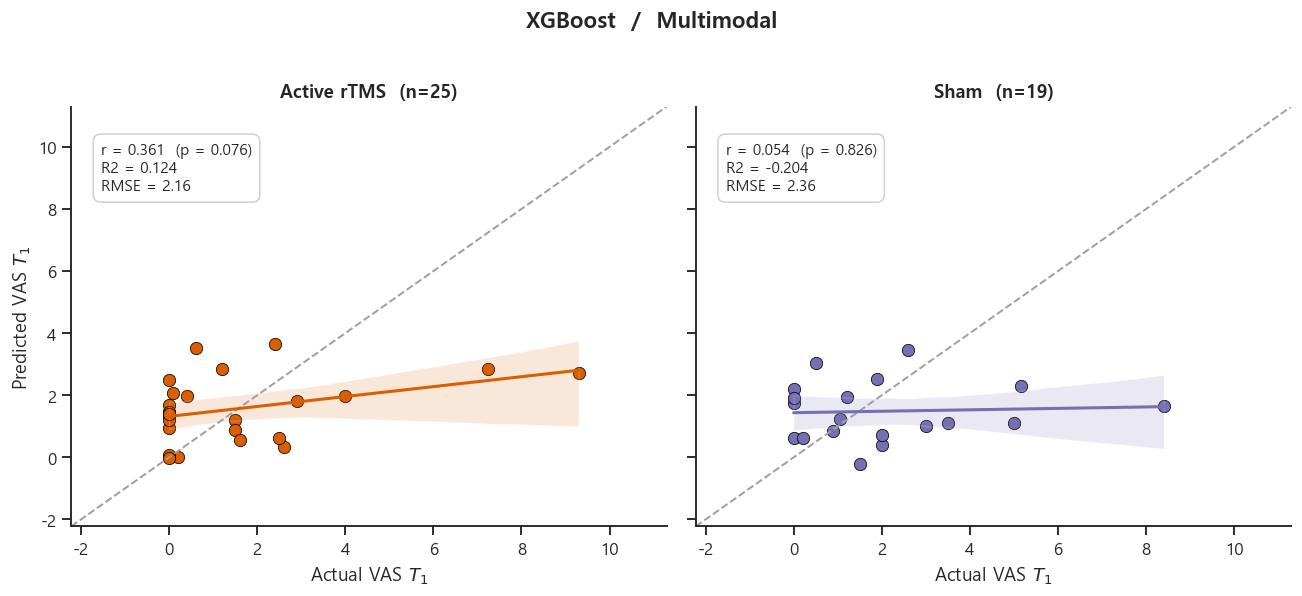

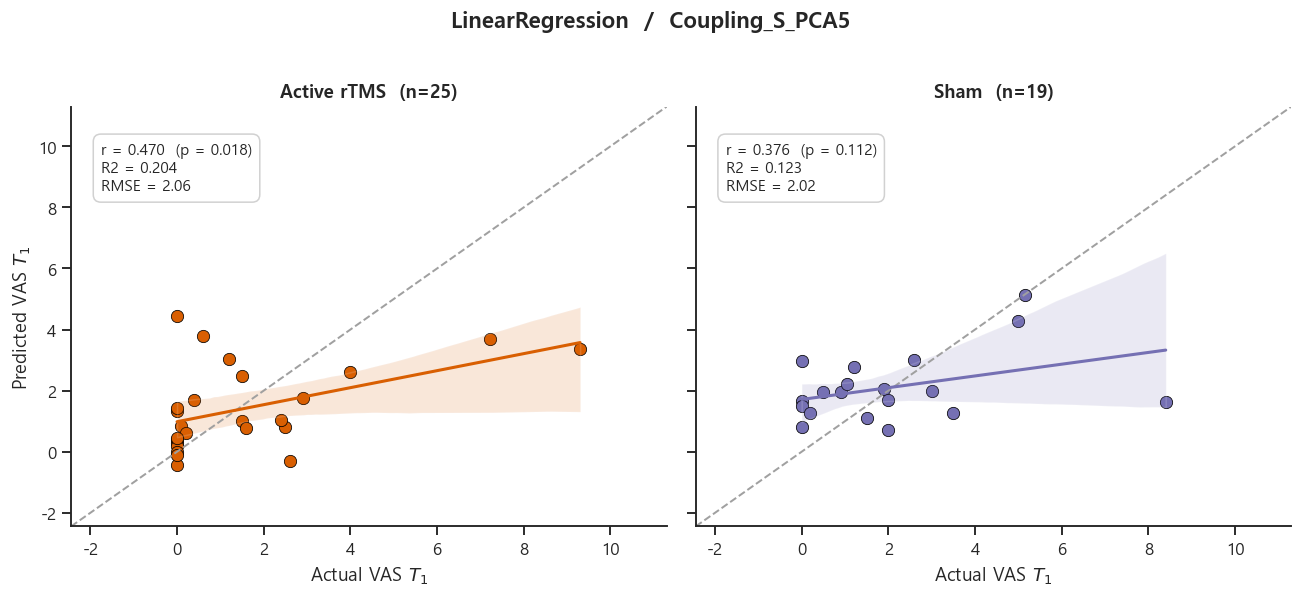

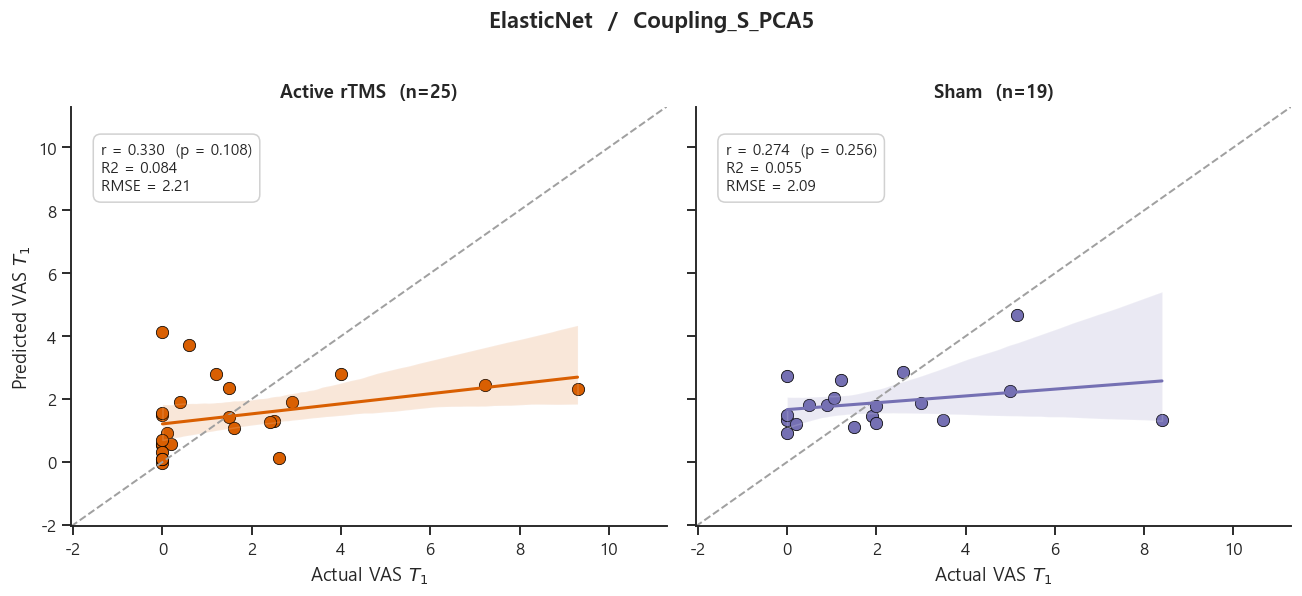

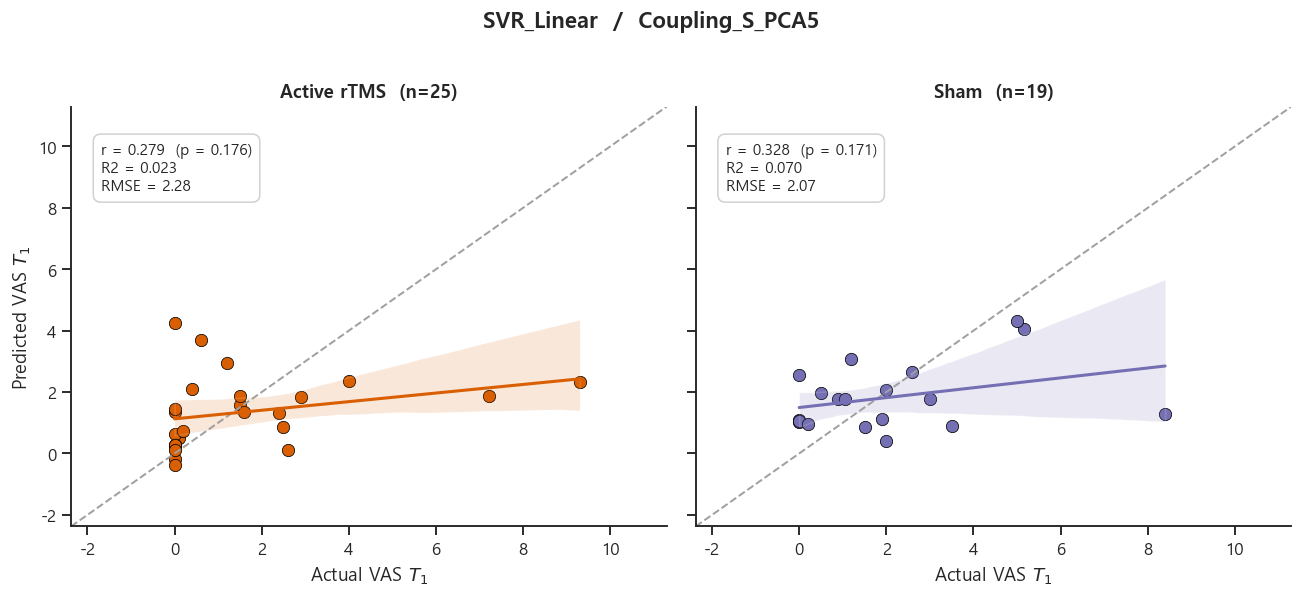

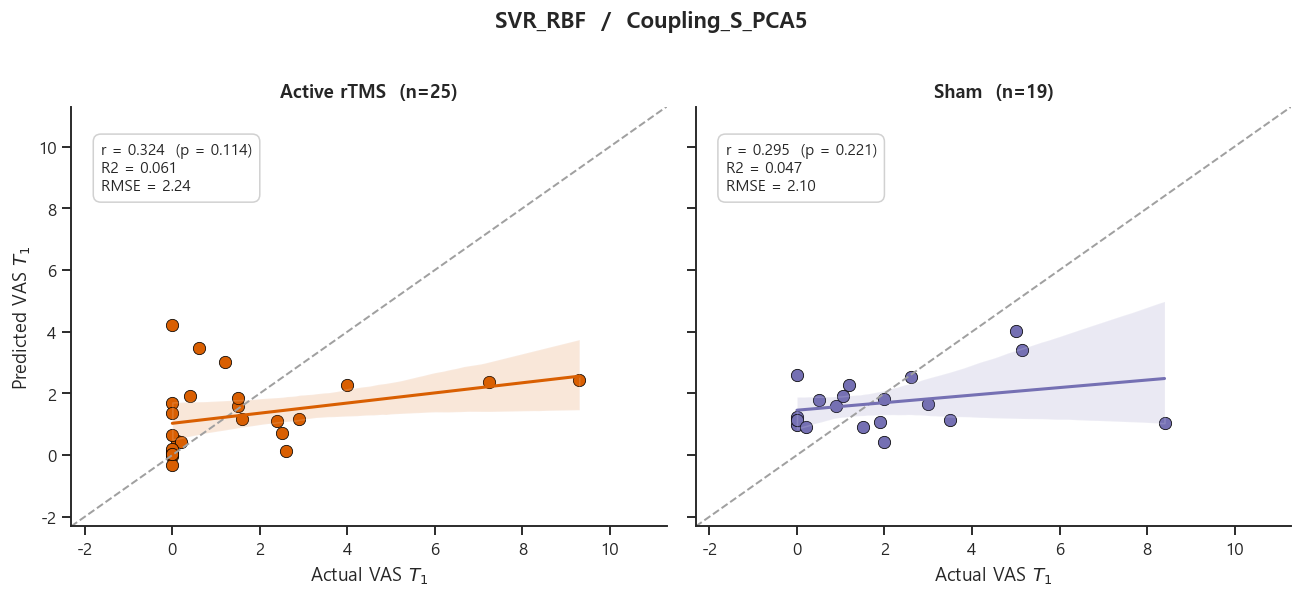

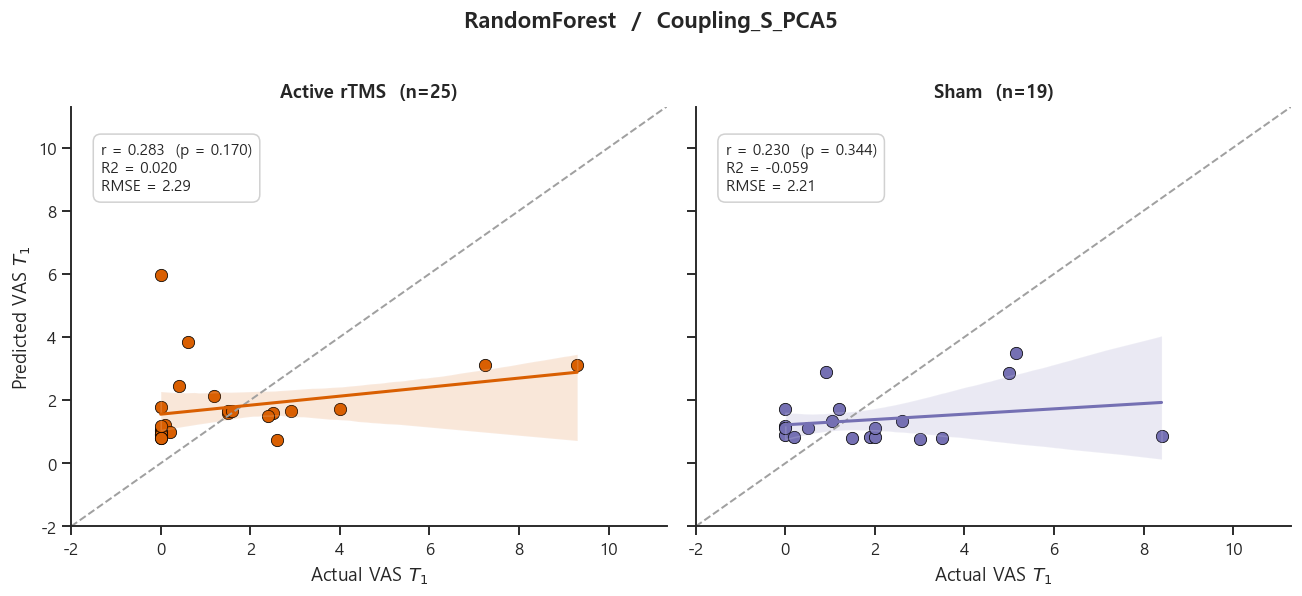

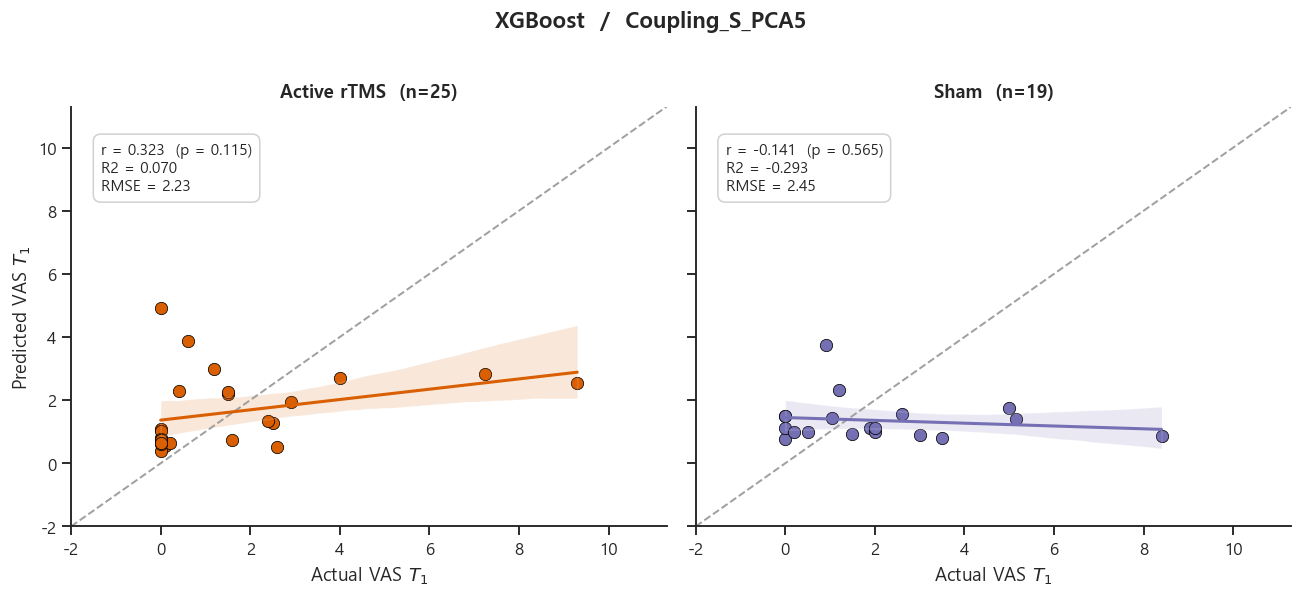

In [10]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['SC_PCA5', 'FC84_PCA5', 'Multimodal', 'Coupling_S_PCA5']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [11]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                            Active                        Sham         \
                                   RMSE     R2      r      p   RMSE     R2   
Data Type       Model                                                        
Clinical_ONLY   LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
                ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
                SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
                SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
                RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
                XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
SC_PCA5         LinearRegression  1.927  0.303  0.561  0.004  2.027  0.113   
                ElasticNet        2.133  0.146  0.406  0.044  2.019  0.119   
                SVR_Linear        2.086  0.183  0.461  0.021  2.154 -0.003   
                SVR_RBF           2.179  0.108  0.382  0.059  2.199 -0.045   
                RandomForest      2.203  0.089  0.344  0.092  2.160 -0.008   
                XGBoost           2.092  0.178  0.432  0.031  2.380 -0.224   
FC84_PCA5       LinearRegression  1.977  0.266  0.533  0.006  2.113  0.035   
                ElasticNet        2.120  0.156  0.418  0.038  2.153 -0.001   
                SVR_Linear        2.083  0.185  0.464  0.019  2.001  0.135   
                SVR_RBF           1.904  0.319  0.567  0.003  2.314 -0.156   
                RandomForest      2.407 -0.087  0.236  0.257  2.079  0.066   
                XGBoost           2.493 -0.167  0.203  0.330  2.269 -0.112   
Multimodal      LinearRegression  1.827  0.373  0.632  0.001  1.995  0.140   
                ElasticNet        2.115  0.160  0.427  0.033  1.988  0.147   
                SVR_Linear        1.905  0.319  0.582  0.002  1.986  0.148   
                SVR_RBF           1.809  0.386  0.623  0.001  2.105  0.043   
                RandomForest      2.269  0.034  0.275  0.184  2.214 -0.059   
                XGBoost           2.160  0.124  0.361  0.076  2.361 -0.204   
Coupling_S_PCA5 LinearRegression  2.059  0.204  0.470  0.018  2.015  0.123   
                ElasticNet        2.209  0.084  0.330  0.108  2.091  0.055   
                SVR_Linear        2.282  0.023  0.279  0.176  2.074  0.070   
                SVR_RBF           2.236  0.061  0.324  0.114  2.101  0.047   
                RandomForest      2.285  0.020  0.283  0.170  2.214 -0.059   
                XGBoost           2.226  0.070  0.323  0.115  2.446 -0.293   

Group                                           
                                      r      p  
Data Type       Model                           
Clinical_ONLY   LinearRegression  0.402  0.088  
                ElasticNet        0.402  0.088  
                SVR_Linear        0.400  0.090  
                SVR_RBF           0.329  0.170  
                RandomForest      0.302  0.209  
                XGBoost           0.307  0.202  
SC_PCA5         LinearRegression  0.372  0.117  
                ElasticNet        0.373  0.115  
                SVR_Linear        0.295  0.220  
                SVR_RBF           0.264  0.275  
                RandomForest      0.282  0.243  
                XGBoost           0.061  0.805  
FC84_PCA5       LinearRegression  0.338  0.157  
                ElasticNet        0.192  0.431  
                SVR_Linear        0.416  0.077  
                SVR_RBF           0.111  0.651  
                RandomForest      0.362  0.128  
                XGBoost           0.129  0.599  
Multimodal      LinearRegression  0.410  0.081  
                ElasticNet        0.402  0.088  
                SVR_Linear        0.428  0.067  
                SVR_RBF           0.292  0.225  
                RandomForest      0.219  0.368  
                XGBoost           0.054  0.826  
Coupling_S_PCA5 LinearRegression  0.376  0.112  
                ElasticNet        0.274  0.256  
    


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type       Model                                                        
Clinical_ONLY   LinearRegression        2.004      1.989     0.507   0.402   
                ElasticNet              2.003      1.988     0.507   0.402   
                SVR_Linear              2.055      2.022     0.475   0.400   
                SVR_RBF                 2.291      2.095     0.358   0.329   
                RandomForest            2.261      2.118     0.356   0.302   
                XGBoost                 2.341      2.089     0.319   0.307   
SC_PCA5         LinearRegression        1.927      2.027     0.561   0.372   
                ElasticNet              2.133      2.019     0.406   0.373   
                SVR_Linear              2.086      2.154     0.461   0.295   
                SVR_RBF                 2.179      2.199     0.382   0.264   
                RandomForest            2.203      2.160     0.344   0.282   
                XGBoost                 2.092      2.380     0.432   0.061   
FC84_PCA5       LinearRegression        1.977      2.113     0.533   0.338   
                ElasticNet              2.120      2.153     0.418   0.192   
                SVR_Linear              2.083      2.001     0.464   0.416   
                SVR_RBF                 1.904      2.314     0.567   0.111   
                RandomForest            2.407      2.079     0.236   0.362   
                XGBoost                 2.493      2.269     0.203   0.129   
Multimodal      LinearRegression        1.827      1.995     0.632   0.410   
                ElasticNet              2.115      1.988     0.427   0.402   
                SVR_Linear              1.905      1.986     0.582   0.428   
                SVR_RBF                 1.809      2.105     0.623   0.292   
                RandomForest            2.269      2.214     0.275   0.219   
                XGBoost                 2.160      2.361     0.361   0.054   
Coupling_S_PCA5 LinearRegression        2.059      2.015     0.470   0.376   
                ElasticNet              2.209      2.091     0.330   0.274   
                SVR_Linear              2.282      2.074     0.279   0.328   
                SVR_RBF                 2.236      2.101     0.324   0.295   
                RandomForest            2.285      2.214     0.283   0.230   
                XGBoost                 2.226      2.446     0.323  -0.141   

                                  RMSE_diff  
Data Type       Model                        
Clinical_ONLY   LinearRegression      0.015  
                ElasticNet            0.015  
                SVR_Linear            0.033  
                SVR_RBF               0.196  
                RandomForest          0.143  
                XGBoost               0.252  
SC_PCA5         LinearRegression     -0.100  
                ElasticNet            0.114  
                SVR_Linear           -0.068  
                SVR_RBF              -0.020  
                RandomForest          0.044  
                XGBoost              -0.289  
FC84_PCA5       LinearRegression     -0.136  
                ElasticNet           -0.033  
                SVR_Linear            0.082  
                SVR_RBF              -0.410  
                RandomForest          0.328  
                XGBoost               0.224  
Multimodal      LinearRegression     -0.168  
                ElasticNet            0.127  
                SVR_Linear           -0.081  
                SVR_RBF              -0.296  
                RandomForest          0.055  
                XGBoost              -0.201  
Coupling_S_PCA5 LinearRegression      0.044  
                ElasticNet            0.118  
                SVR_Linear            0.207  
                SVR_RBF               0.136  
                RandomForest          0.071  
                XGBoost              -0.221


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,Multimodal,SVR_RBF,1.809,0.386,0.623,0.001
1,Multimodal,LinearRegression,1.827,0.373,0.632,0.001
2,FC84_PCA5,SVR_RBF,1.904,0.319,0.567,0.003
3,Multimodal,SVR_Linear,1.905,0.319,0.582,0.002
4,SC_PCA5,LinearRegression,1.927,0.303,0.561,0.004



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,Multimodal,SVR_Linear,1.986,0.148,0.428,0.067
1,Multimodal,ElasticNet,1.988,0.147,0.402,0.088
2,Clinical_ONLY,ElasticNet,1.988,0.146,0.402,0.088
3,Clinical_ONLY,LinearRegression,1.989,0.145,0.402,0.088
4,Multimodal,LinearRegression,1.995,0.140,0.410,0.081
